

# MEEP - Simulation in 1D

We will demonstrate the principle of simulating the propagation of an electromagnetic wave in a medium using the *meep* simulator with a simple one-dimensional example.

The environment consists of a linear sequence of nodes representing the simulation area along the **Z-axis**. The simulation area is bounded at its edges by an ideal absorber called a **PML (Perfectly Matched Layer)**.

Inside this area, the simulation includes:
* A **pulse generator** at one end, which creates a wave with an electric field component in the x-direction ($E_x$).
* A **perfect metal conductor (M)** at the other end, defined with a relative permittivity of $\epsilon_r = \infty$.
* The nodes of the environment marked **V** represent a perfect **vacuum**.

<img src="./img/obr_1d_config.png" width="350" alt="Configuration of the one-dimensional simulation environment">

*Caption: Configuration of the one-dimensional simulation environment.*

## Installation of simulation

In [2]:
%matplotlib inline

import meep as mp
import pylab as plt
from scipy import *
import numpy as np 



## Definition of the Simulation Area

The definition of the simulation area consists of two main steps:
1.  Defining the dimensions of the overall simulation area (the "computational cell").
2.  Creating a list of geometric objects to be placed within that area.

Objects that are defined to extend beyond the boundaries of the simulation area will be ignored or clipped.

Around the simulated area (on the inner side of its boundaries), it is possible to create an ideal absorber—a **Perfectly Matched Layer (PML)**—with a user-defined thickness.

In [4]:
size = 200                        # number of cells in the simulation
res = 20                          # resolution - division of cells

area = mp.Vector3(0, 0, size)     # defining the dimensions of the simulation area (1D)
                                  # in the direction of the Z-axis

geometry = [                      # definition of the environment's properties using 1D blocks
    mp.Block(mp.Vector3(0,0,size-2), 
             center=mp.Vector3(0,0,0),          
             material=mp.vacuum),
    mp.Block(mp.Vector3(0,0,1),      
             center=mp.Vector3(0,0,size/2-1.5), 
             material=mp.metal) 
  ]

pml_layers = mp.PML(1.0)          # ideal absorber around the simulation area



### Creating and Defining Sources

In addition to a set of predefined source types, *meep* also allows for the definition of custom sources. In our case, we will define a source that generates a pulse in the shape of a Gaussian curve, shifted in time by $t_0$ and with a width of $w$.

The time profile of the source is given by the equation:
$$
s(t) = \exp \left( -\frac{(t - t_0)^2}{w} \right)
$$

There can be several sources in the simulated environment. For each source definition, we must specify its **position**, the **electromagnetic wave component** it affects (e.g., $E_x$), and its **amplitude**. All defined sources are then placed into a list, which is passed as a parameter to the main simulation object.

In [5]:
def pulse(t):
    return -2*np.exp(-(t -20.0)**2 / 20.0)

sources = [mp.Source(mp.CustomSource(src_func=pulse), 
                component=mp.Ex,
                center=mp.Vector3(0, 0, -size/2 + 1),  
                amplitude=1.0)
          ]



## Creating the Simulation Object

We pass the dimensions of the simulation area, the list of objects in the area, and the list of sources as parameters to the `Simulation` class.

In [6]:
sim = mp.Simulation(               # vytvorenie objektu simulacie s parametrami
    cell_size=area,                
    geometry=geometry,
    sources=sources,
    boundary_layers=[pml_layers],
    resolution=res,
    dimensions=1)



## Simulation

We can run the simulation using the `run` method, passing an argument that specifies the total duration of the simulation.

In [7]:
sim.run(until=70)     # doba simulacie 200 krokov, impul je oneskoreny 20 jednotiek
data_1 = sim.get_efield_x()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000123978 s
Working in 1D dimensions.
Computational cell is 0 x 0 x 200 with resolution 20
     block, center = (0,0,0)
          size (0,0,198)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,0,98.5)
          size (0,0,1)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
time for set_epsilon = 0.00086689 s
-----------


FloatProgress(value=0.0, description='0% done ', max=70.0)

run 0 finished at t = 70.0 (2800 timesteps)


In [8]:
sim.run(until=200)     # pokracovanie simulacie o dalsich 200 krokov
data_2 = sim.get_efield_x()

FloatProgress(value=70.0, description='0% done ', max=270.0, min=70.0)

on time step 2800 (time=70), 0.0024208 s/step
run 1 finished at t = 270.0 (10800 timesteps)


## Visualization

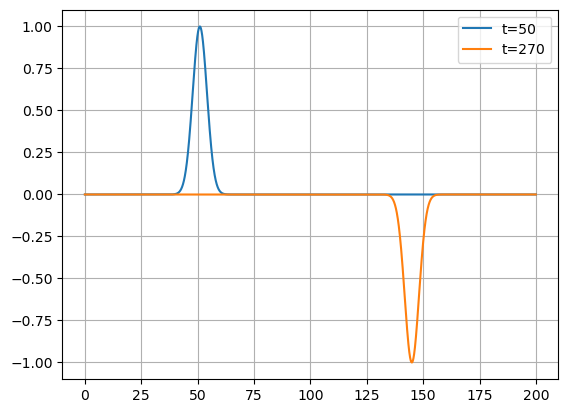

In [9]:
x = np.arange(len(data_1))/res

plt.plot(x, np.real(data_1), label='t=50')  # pulse at time 70 units, position 52 - the source is at position [1]
plt.plot(x, np.real(data_2), label='t=270')  # impulz v case 270, poloha 158 - dlzka oblasti je 200 - 4 
plt.grid()
plt.legend()
plt.show()

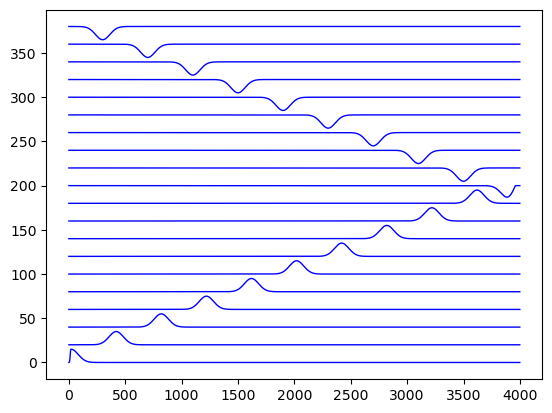

In [10]:
from IPython.utils import io

sim.reset_meep()                    # restart simulation

fig = plt.figure() # figsize=(10, 7), facecolor='r')
ax = fig.add_subplot(111)

for i in range(20):
    with io.capture_output() as captured:
        sim.run(until=20);     # continuation of the simulation by another 200 steps
    data = np.real(sim.get_efield_x()) * 15
    ax.plot(data +i*20, 'b', lw=1) 
plt.show()